## Pembacaan dan Inspeksi Data Awal

In [68]:
import pandas as pd

# 1. Membaca dataset
df_raw = pd.read_csv("../data/clackamas_river.csv")

# 2. Dictionary untuk mengubah nama kolom sesuai kebutuhanmu
rename_dict = {
    "00010_Mean": "Temperature",
    "00300_Mean": "Dissolved Oxygen",
    "00400_Median": "pH",
    "63680_Median": "Turbidity"
}

# 3. Memilih hanya kolom 'datetime' dan 4 fitur target
# Ini akan membuat memori komputermu jauh lebih lega karena membuang kolom yang tidak dipakai
selected_columns = ['datetime'] + list(rename_dict.keys())
df = df_raw[selected_columns].copy()

# 4. Mengubah nama kolom
df = df.rename(columns=rename_dict)

# 5. Mengubah tipe data 'datetime' dengan pengaman errors='coerce'
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')

# Cek berapa banyak baris yang format waktunya rusak
baris_rusak = df['datetime'].isna().sum()
print(f"Jumlah baris yang rusak dan diabaikan: {baris_rusak} baris")

# Buang baris yang rusak (NaT) tersebut
df = df.dropna(subset=['datetime'])

# 6. Menyetel kolom 'datetime' menjadi index dataframe
df = df.set_index('datetime')

# 7. Memfilter data hanya untuk 10 tahun (2014 hingga 2023)
# Menggunakan .loc pada DatetimeIndex sangat praktis untuk memotong rentang tahun
df = df.loc['2014':'2023']

# 8. Menampilkan ringkasan struktur data dan 5 baris pertama
print("\n--- Info Data Setelah Filter 10 Tahun ---")
print(df.info())
print("\n--- 5 Baris Pertama ---")
print(df.head())
print("\n--- 5 Baris Terakhir ---")
print(df.tail())

Jumlah baris yang rusak dan diabaikan: 217 baris

--- Info Data Setelah Filter 10 Tahun ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3562 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       3560 non-null   float64
 1   Dissolved Oxygen  3541 non-null   float64
 2   pH                3522 non-null   float64
 3   Turbidity         3512 non-null   float64
dtypes: float64(4)
memory usage: 139.1 KB
None

--- 5 Baris Pertama ---
                           Temperature  Dissolved Oxygen   pH  Turbidity
datetime                                                                
2014-01-01 00:00:00+00:00          4.9              13.3  7.0        0.5
2014-01-02 00:00:00+00:00          4.8              13.2  7.1        0.5
2014-01-03 00:00:00+00:00          5.0              13.1  7.0        2.1
2014-01-04 00:00:00+00:00          

--- 1. Statistik Deskriptif ---
       Temperature  Dissolved Oxygen           pH    Turbidity
count  3560.000000       3541.000000  3522.000000  3512.000000
mean     11.504775         11.134425     7.526917     2.579584
std       5.604703          1.414884     0.269678     4.771787
min       0.900000          8.200000     6.800000     0.100000
25%       6.700000          9.900000     7.300000     0.800000
50%      10.100000         11.400000     7.500000     1.400000
75%      16.200000         12.300000     7.700000     2.500000
max      23.900000         14.500000     8.400000    91.600000

--- 2. Laporan Hari yang Hilang ---
Total hari yang hilang dari sensor: 90 hari
Contoh 5 tanggal yang hilang: ['2014-10-05', '2014-10-06', '2014-11-21', '2014-11-22', '2014-11-23']

Total baris setelah reindex: 3652 baris (Seharusnya 3652)

--- 3. Total Nilai Kosong (NaN) per Fitur ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


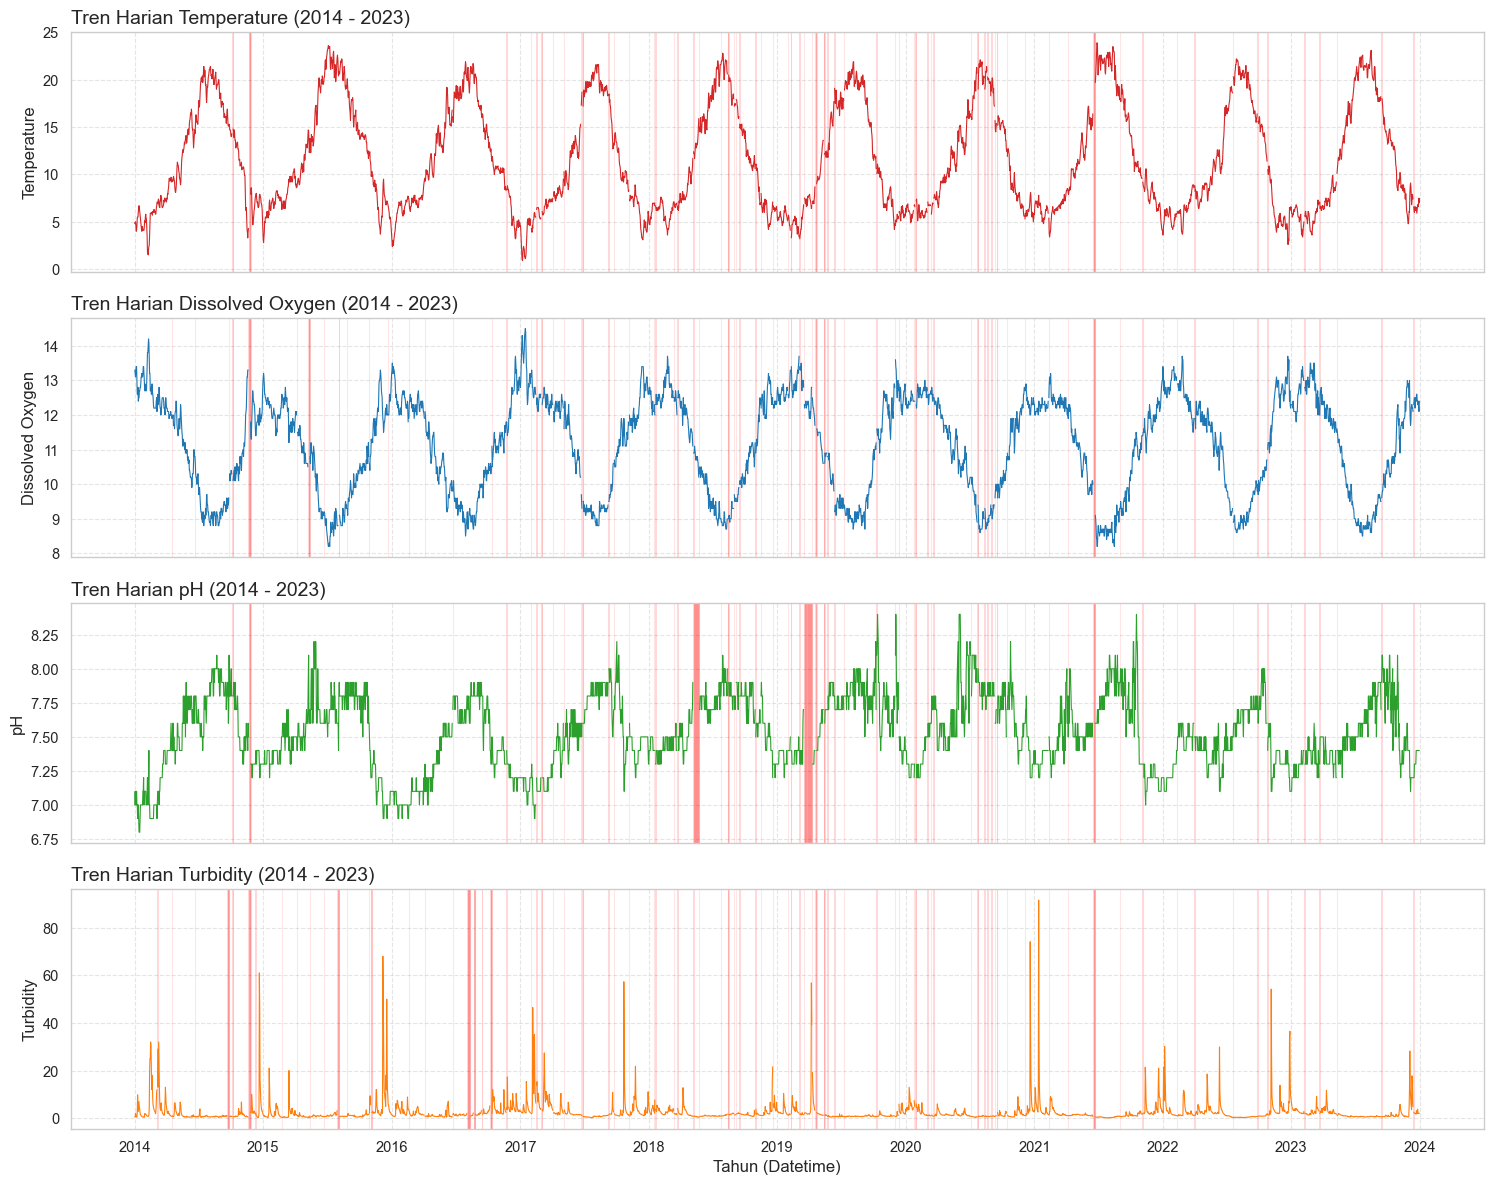

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Menampilkan Statistik Deskriptif
print("--- 1. Statistik Deskriptif ---")
# Gunakan display(df.describe()) jika di Jupyter Notebook agar tabel lebih rapi
print(df.describe())

# 2. Mencari Hari yang Hilang Secara Total (Missing Dates)
# Membuat rentang kalender penuh dari 1 Jan 2014 hingga 31 Des 2023 setiap hari ('D')
full_date_range = pd.date_range(start='2014-01-01', end='2023-12-31', freq='D', tz='UTC')

# Membandingkan kalender penuh dengan tanggal yang ada di dataset kita
missing_dates = full_date_range.difference(df.index)
print(f"\n--- 2. Laporan Hari yang Hilang ---")
print(f"Total hari yang hilang dari sensor: {len(missing_dates)} hari")
if len(missing_dates) > 0:
    print("Contoh 5 tanggal yang hilang:", [date.strftime('%Y-%m-%d') for date in missing_dates[:5]])

# 3. Menyelaraskan ulang (Reindex) Data
# Ini WAJIB dilakukan. Kita memaksa dataframe agar memiliki 3.652 baris. 
# Hari yang sebelumnya tidak ada akan ditambahkan otomatis dengan nilai NaN.
df = df.reindex(full_date_range)
df.index.name = 'datetime'

print(f"\nTotal baris setelah reindex: {len(df)} baris (Seharusnya 3652)")

# 4. Mengecek Total Missing Values (Bolong bawaan + Bolong dari hari yang hilang)
print("\n--- 3. Total Nilai Kosong (NaN) per Fitur ---")
print(df.isna().sum())

# 5. Visualisasi Plot Time Series (EDA)
# Membuat 4 grafik bertumpuk agar fluktuasi dan kekosongan data terlihat jelas
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)
features = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'] # Merah, Biru, Hijau, Oranye

for i, col in enumerate(features):
    # Plot data dengan garis tipis dan titik kecil
    axes[i].plot(df.index, df[col], color=colors[i], linestyle='-', linewidth=0.8)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f"Tren Harian {col} (2014 - 2023)", fontsize=14, loc='left')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    # Highlight area dengan nilai NaN menggunakan background merah muda transparan
    # Ini akan menunjukkan di bulan/tahun berapa sensor mati total
    missing_mask = df[col].isna()
    for j in range(len(missing_mask) - 1):
        if missing_mask.iloc[j]:
            axes[i].axvspan(df.index[j], df.index[j+1], color='red', alpha=0.1)

plt.xlabel("Tahun (Datetime)", fontsize=12)
plt.tight_layout()
plt.show()

In [70]:
import plotly.express as px

# Daftar 4 fitur yang akan kita plot
features = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']

# Warna yang berbeda untuk setiap fitur agar lebih estetik
colors = ['#EF553B', '#00CC96', '#AB63FA', '#FFA15A'] 

# Looping untuk membuat dan menampilkan plot interaktif satu per satu
for i, col in enumerate(features):
    fig = px.histogram(
        df, 
        x=col, 
        marginal="box", # Kunci utamanya: menambahkan boxplot di bagian atas
        title=f"Distribusi dan Boxplot Historis: {col}",
        color_discrete_sequence=[colors[i]],
        opacity=0.8,
        nbins=50 # Menentukan seberapa detail potongan bar histogramnya
    )
    
    # Merapikan tampilan layout
    fig.update_layout(
        xaxis_title=f"Nilai {col}",
        yaxis_title="Frekuensi (Jumlah Hari)",
        bargap=0.05,
        plot_bgcolor='white'
    )
    
    # Menambahkan garis grid agar lebih mudah dibaca
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
    
    # Menampilkan plot interaktif
    fig.show()

## Step 3: Imputasi

In [71]:
# 1. Cek kondisi sebelum imputasi (sebagai pengingat)
print("--- Missing Values SEBELUM Imputasi ---")
print(df.isna().sum())

# 2. Proses Imputasi: Interpolasi Linear
# Limit direction 'both' memastikan bisa menambal ke depan dan ke belakang
df = df.interpolate(method='linear', limit_direction='both')

# 3. Langkah Pengaman Tambahan (Foward/Backward Fill)
# Terkadang interpolasi gagal jika data di baris paling pertama atau terakhir kosong.
# Kita gunakan bfill (isi mundur) dan ffill (isi maju) untuk memastikan tidak ada yang tersisa.
df = df.bfill().ffill()

# 4. Cek kondisi sesudah imputasi
print("\n--- Missing Values SESUDAH Imputasi ---")
print(df.isna().sum())

# 5. Mari kita lihat sekilas data yang sudah utuh
print("\n--- 5 Baris Pertama Data Bersih ---")
print(df.head())
print(df.shape)

--- Missing Values SEBELUM Imputasi ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64

--- Missing Values SESUDAH Imputasi ---
Temperature         0
Dissolved Oxygen    0
pH                  0
Turbidity           0
dtype: int64

--- 5 Baris Pertama Data Bersih ---
                           Temperature  Dissolved Oxygen   pH  Turbidity
datetime                                                                
2014-01-01 00:00:00+00:00          4.9              13.3  7.0        0.5
2014-01-02 00:00:00+00:00          4.8              13.2  7.1        0.5
2014-01-03 00:00:00+00:00          5.0              13.1  7.0        2.1
2014-01-04 00:00:00+00:00          4.6              13.3  7.1        1.0
2014-01-05 00:00:00+00:00          4.0              13.4  7.0        0.6
(3652, 4)


## Step 4: Feature Engineering

In [72]:
import numpy as np
# Membuat salinan dataframe agar data asli (df) tetap utuh
df_feat = df.copy()

# 1. Fitur Temporal (Musiman)
# Mengekstrak angka bulan (1-12) agar model paham siklus musim kemarau/hujan
# ==========================================
# REVISI TAHAP 4: CYCLICAL ENCODING
# ==========================================
# Buang kolom 'Month' yang lama (jika ada)
if 'Month' in df_feat.columns:
    df_feat = df_feat.drop(columns=['Month'])

# Buat fitur siklikal bulan
df_feat['Month_Sin'] = np.sin(2 * np.pi * df_feat.index.month / 12)
df_feat['Month_Cos'] = np.cos(2 * np.pi * df_feat.index.month / 12)

# Daftar 4 fitur dasar yang akan direkayasa
base_features = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']

# Menjinakkan nilai ekstrem Turbidity sebelum diproses macam-macam
df['Turbidity'] = np.log1p(df['Turbidity'])

# 2. Rekayasa Fitur Dinamis (Lag & Rolling)
for col in base_features:
    # a. Fitur Lag (Perbedaan 1 Hari) - Menangkap perubahan mendadak/drastis
    df_feat[f'{col}_Diff'] = df_feat[col].diff()
    
    # b. Fitur Tren Mingguan (Rolling Mean 7 Hari) - Menangkap kondisi normal dalam seminggu
    df_feat[f'{col}_Mean_7D'] = df_feat[col].rolling(window=7, min_periods=1).mean()
    
    # c. Fitur Volatilitas (Rolling Std 7 Hari) - Menangkap ketidakstabilan sensor
    df_feat[f'{col}_Std_7D'] = df_feat[col].rolling(window=7, min_periods=2).std()

# 3. Membersihkan efek samping Feature Engineering
# Fungsi diff() dan rolling().std() pasti menghasilkan NaN di baris-baris pertama
# Kita tambal NaN tersebut dengan cara 'bfill' (isi mundur) dari baris setelahnya
df_feat = df_feat.bfill()

# 4. Mari kita lihat hasilnya
print("--- Info Struktur Data Baru ---")
print(df_feat.info())

print("\n--- Contoh Hasil Rekayasa Fitur (Fokus di Temperature) ---")
# Menampilkan hanya fitur terkait Suhu agar mudah dipahami di layar
cols_to_show = ['Temperature', 'Temperature_Diff', 'Temperature_Mean_7D', 'Temperature_Std_7D']
print(df_feat[cols_to_show].head(10))

--- Info Struktur Data Baru ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3652 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Freq: D
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               3652 non-null   float64
 1   Dissolved Oxygen          3652 non-null   float64
 2   pH                        3652 non-null   float64
 3   Turbidity                 3652 non-null   float64
 4   Month_Sin                 3652 non-null   float64
 5   Month_Cos                 3652 non-null   float64
 6   Temperature_Diff          3652 non-null   float64
 7   Temperature_Mean_7D       3652 non-null   float64
 8   Temperature_Std_7D        3652 non-null   float64
 9   Dissolved Oxygen_Diff     3652 non-null   float64
 10  Dissolved Oxygen_Mean_7D  3652 non-null   float64
 11  Dissolved Oxygen_Std_7D   3652 non-null   float64
 12  pH_Diff                   3652

## Step 5 dan 6

In [73]:
from sklearn.preprocessing import RobustScaler
# ==========================================
# REVISI TAHAP 5 & 6: SPLITTING & SELECTIVE SCALING
# ==========================================
# 1. Split Data
train_df = df_feat.loc['2014':'2020'].copy()
val_df   = df_feat.loc['2021'].copy()
test_df  = df_feat.loc['2022':'2023'].copy()

# 2. Pisahkan kolom yang butuh di-scale (Suhu, pH, dll) dan yang tidak (Sin/Cos)
cyclical_cols = ['Month_Sin', 'Month_Cos']
cols_to_scale = [col for col in train_df.columns if col not in cyclical_cols]

# 3. Fit scaler HANYA pada kolom kontinu di Train Set
scaler = RobustScaler()
scaler.fit(train_df[cols_to_scale])

# 4. Buat fungsi bantuan untuk transform agar rapi
def scale_dataframe(df_target, scaler_obj, scale_cols, pass_cols):
    # Scale kolom numerik kontinu
    scaled_array = scaler_obj.transform(df_target[scale_cols])
    df_scaled = pd.DataFrame(scaled_array, columns=scale_cols, index=df_target.index)
    
    # Gabungkan kembali dengan kolom Sin/Cos yang tidak di-scale
    df_final = pd.concat([df_scaled, df_target[pass_cols]], axis=1)
    return df_final

# 5. Transform semua dataset
train_scaled = scale_dataframe(train_df, scaler, cols_to_scale, cyclical_cols)
val_scaled   = scale_dataframe(val_df, scaler, cols_to_scale, cyclical_cols)
test_scaled  = scale_dataframe(test_df, scaler, cols_to_scale, cyclical_cols)

print("--- Contoh Data Train Set Setelah Revisi ---")
print(train_scaled[['Temperature', 'Turbidity', 'Month_Sin', 'Month_Cos']].head())

--- Contoh Data Train Set Setelah Revisi ---
                           Temperature  Turbidity  Month_Sin  Month_Cos
datetime                                                               
2014-01-01 00:00:00+00:00    -0.563830  -0.529412        0.5   0.866025
2014-01-02 00:00:00+00:00    -0.574468  -0.529412        0.5   0.866025
2014-01-03 00:00:00+00:00    -0.553191   0.411765        0.5   0.866025
2014-01-04 00:00:00+00:00    -0.595745  -0.235294        0.5   0.866025
2014-01-05 00:00:00+00:00    -0.659574  -0.470588        0.5   0.866025


## Step 7

In [74]:
import numpy as np

# ==========================================
# TAHAP 7: SYNTHETIC ANOMALY INJECTION
# ==========================================

# Set seed agar hasil acak selalu sama (reproducible) setiap kali di-run. 
# Ini sangat penting untuk konsistensi hasil di laporan skripsi!
np.random.seed(42)

# 1. Buat kolom 'Label' (0 = Normal, 1 = Anomali)
val_scaled['Label'] = 0
test_scaled['Label'] = 0

# 2. Fungsi untuk menyuntikkan anomali secara logis
def inject_anomalies(df, num_univariate=5, num_multivariate=5):
    df_injected = df.copy()
    
    # --- SKENARIO 1: UNIVARIAT (Misal: Sensor Kekeruhan Rusak / Limbah Tunggal) ---
    # Ambil tanggal acak
    random_dates_uni = np.random.choice(df_injected.index, size=num_univariate, replace=False)
    
    for date in random_dates_uni:
        df_injected.loc[date, 'Turbidity'] += 15.0 # Perbesar dosis univariat
        df_injected.loc[date, 'Turbidity_Diff'] += 15.0
        
        # Tandai sebagai anomali
        df_injected.loc[date, 'Label'] = 1
        
    # --- SKENARIO 2: MULTIVARIAT (Misal: Kerusakan Ekosistem / Algae Bloom) ---
    # Ambil tanggal acak lain yang belum jadi anomali
    remaining_dates = df_injected[df_injected['Label'] == 0].index
    random_dates_multi = np.random.choice(remaining_dates, size=num_multivariate, replace=False)
    
    for date in random_dates_multi:
        # Logika Fisik: Suhu air tiba-tiba naik sangat panas (+4.0), 
        # yang secara alamiah menyebabkan Oksigen Terlarut (DO) anjlok parah (-4.0)
        df_injected.loc[date, 'Temperature'] += 10.0
        df_injected.loc[date, 'Dissolved Oxygen'] -= 10.0
        
        # Tandai sebagai anomali
        df_injected.loc[date, 'Label'] = 1
        
    return df_injected

# 3. Terapkan injeksi pada Validation dan Test set
# Kita suntikkan sedikit di Validation (untuk tuning) dan lebih banyak di Test (untuk ujian akhir)
val_injected = inject_anomalies(val_scaled, num_univariate=18, num_multivariate=18)
test_injected = inject_anomalies(test_scaled, num_univariate=36, num_multivariate=36)

# 4. Tampilkan Laporan
print("--- Laporan Kunci Jawaban (Ground Truth) Buatan ---")
print(f"Total Hari Normal di Validation Set  : {len(val_injected[val_injected['Label'] == 0])}")
print(f"Total Hari Anomali di Validation Set : {len(val_injected[val_injected['Label'] == 1])}")
print(f"Total Hari Normal di Test Set        : {len(test_injected[test_injected['Label'] == 0])}")
print(f"Total Hari Anomali di Test Set       : {len(test_injected[test_injected['Label'] == 1])}")

print("\n--- Intip Data Anomali Multivariat di Test Set ---")
contoh_multi = test_injected[test_injected['Label'] == 1].tail(3)
print(contoh_multi[['Temperature', 'Dissolved Oxygen', 'Turbidity', 'Label']])

--- Laporan Kunci Jawaban (Ground Truth) Buatan ---
Total Hari Normal di Validation Set  : 329
Total Hari Anomali di Validation Set : 36
Total Hari Normal di Test Set        : 658
Total Hari Anomali di Test Set       : 72

--- Intip Data Anomali Multivariat di Test Set ---
                           Temperature  Dissolved Oxygen  Turbidity  Label
datetime                                                                  
2023-10-24 00:00:00+00:00    10.148936        -10.250000  -0.411765      1
2023-11-23 00:00:00+00:00     9.755319         -9.666667  -0.294118      1
2023-11-27 00:00:00+00:00    -0.478723          0.666667  14.529412      1


## Step 8

In [75]:
from sklearn.ensemble import IsolationForest

# ==========================================
# TAHAP 8: MELATIH MODEL ISOLATION FOREST
# ==========================================

# 1. Pastikan kita hanya mengambil kolom fitur (tanpa kolom Label yang ada di Val/Test set)
feature_cols = train_scaled.columns.tolist()

# 2. Inisialisasi Model
# n_estimators: Jumlah "pohon" yang akan dibangun (100 adalah standar yang bagus)
# contamination: Estimasi persentase anomali di data historis. 
# Kita set 0.01 (1%) sebagai tebakan awal. Nanti di Tahap 9 kita akan cari nilai terbaiknya.
# random_state=42: Agar hasil tebangan pohonnya konsisten setiap kali di-run
iforest_model = IsolationForest(
    n_estimators=500, 
    max_samples='auto', 
    contamination=0.05, 
    random_state=42
)

# 3. Latih (Fit) Model HANYA menggunakan Train Set
print("Sedang melatih model Isolation Forest...")
iforest_model.fit(train_scaled[feature_cols])
print("✅ Pelatihan model selesai!")

# 4. Cek bagaimana model menilai Train Set itu sendiri
# Bawaan scikit-learn: 1 = Normal (Inlier), -1 = Anomali (Outlier)
train_predictions = iforest_model.predict(train_scaled[feature_cols])

# Kita konversi agar formatnya sama dengan Label buatan kita: 
# 0 = Normal, 1 = Anomali
train_pred_mapped = [1 if x == -1 else 0 for x in train_predictions]

total_train = len(train_pred_mapped)
total_anomali_train = sum(train_pred_mapped)

print("\n--- Ringkasan Hasil Training ---")
print(f"Dari {total_train} hari data historis (Train Set),")
print(f"Model menganggap ada {total_anomali_train} hari ({total_anomali_train/total_train*100:.2f}%) sebagai 'Outlier Alami'.")

Sedang melatih model Isolation Forest...
✅ Pelatihan model selesai!

--- Ringkasan Hasil Training ---
Dari 2557 hari data historis (Train Set),
Model menganggap ada 128 hari (5.01%) sebagai 'Outlier Alami'.


## Step 9

In [76]:
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import IsolationForest

# ==========================================
# TAHAP 9: VALIDASI & HYPERPARAMETER TUNING
# ==========================================

# 1. Tentukan rentang parameter contamination yang akan diuji
contamination_kandidat = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1]
best_f1 = 0
best_contamination = 0

print("--- Memulai Hyperparameter Tuning ---")

# 2. Looping untuk mencari parameter terbaik
for cont in contamination_kandidat:
    # Inisialisasi model
    model = IsolationForest(n_estimators=100, contamination=cont, random_state=42)
    
    # Fit HANYA menggunakan Train Set (Belajar dari data normal)
    model.fit(train_scaled[feature_cols])
    
    # Prediksi menggunakan Validation Set (Tahun 2021)
    val_preds = model.predict(val_injected[feature_cols])
    
    # Konversi output Scikit-Learn (-1 = Anomali, 1 = Normal) 
    # menjadi format Label kita (1 = Anomali, 0 = Normal)
    val_preds_mapped = [1 if x == -1 else 0 for x in val_preds]
    
    # Ambil Kunci Jawaban
    y_true = val_injected['Label']
    y_pred = val_preds_mapped
    
    # Hitung F1-Score
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"Contamination: {cont} | F1-Score: {f1:.4f}")
    
    # Simpan parameter dengan skor tertinggi
    if f1 > best_f1:
        best_f1 = f1
        best_contamination = cont

print("\n--- Kesimpulan Tuning ---")
print(f"Parameter Terbaik: contamination = {best_contamination} (F1-Score: {best_f1:.4f})")

# ==========================================
# MELATIH MODEL FINAL
# ==========================================
# 3. Latih ulang model dengan parameter terbaik yang baru saja ditemukan
final_model = IsolationForest(n_estimators=100, contamination=best_contamination, random_state=42)
final_model.fit(train_scaled[feature_cols])

# 4. Evaluasi Detail pada Validation Set
final_val_preds = final_model.predict(val_injected[feature_cols])
final_val_preds_mapped = [1 if x == -1 else 0 for x in final_val_preds]

print("\n--- Laporan Klasifikasi Final (Validation Set) ---")
print(classification_report(val_injected['Label'], final_val_preds_mapped, target_names=['Normal', 'Anomali'], zero_division=0))

--- Memulai Hyperparameter Tuning ---
Contamination: 0.005 | F1-Score: 0.0000
Contamination: 0.01 | F1-Score: 0.0000
Contamination: 0.02 | F1-Score: 0.1000
Contamination: 0.03 | F1-Score: 0.0851
Contamination: 0.05 | F1-Score: 0.2581
Contamination: 0.1 | F1-Score: 0.4571

--- Kesimpulan Tuning ---
Parameter Terbaik: contamination = 0.1 (F1-Score: 0.4571)

--- Laporan Klasifikasi Final (Validation Set) ---
              precision    recall  f1-score   support

      Normal       0.96      0.86      0.91       329
     Anomali       0.35      0.67      0.46        36

    accuracy                           0.84       365
   macro avg       0.65      0.76      0.68       365
weighted avg       0.90      0.84      0.86       365



## Step 10

--- LAPORAN KLASIFIKASI FINAL (TEST SET: 2022-2023) ---
              precision    recall  f1-score   support

      Normal       0.95      0.92      0.93       658
     Anomali       0.44      0.58      0.50        72

    accuracy                           0.88       730
   macro avg       0.70      0.75      0.72       730
weighted avg       0.90      0.88      0.89       730



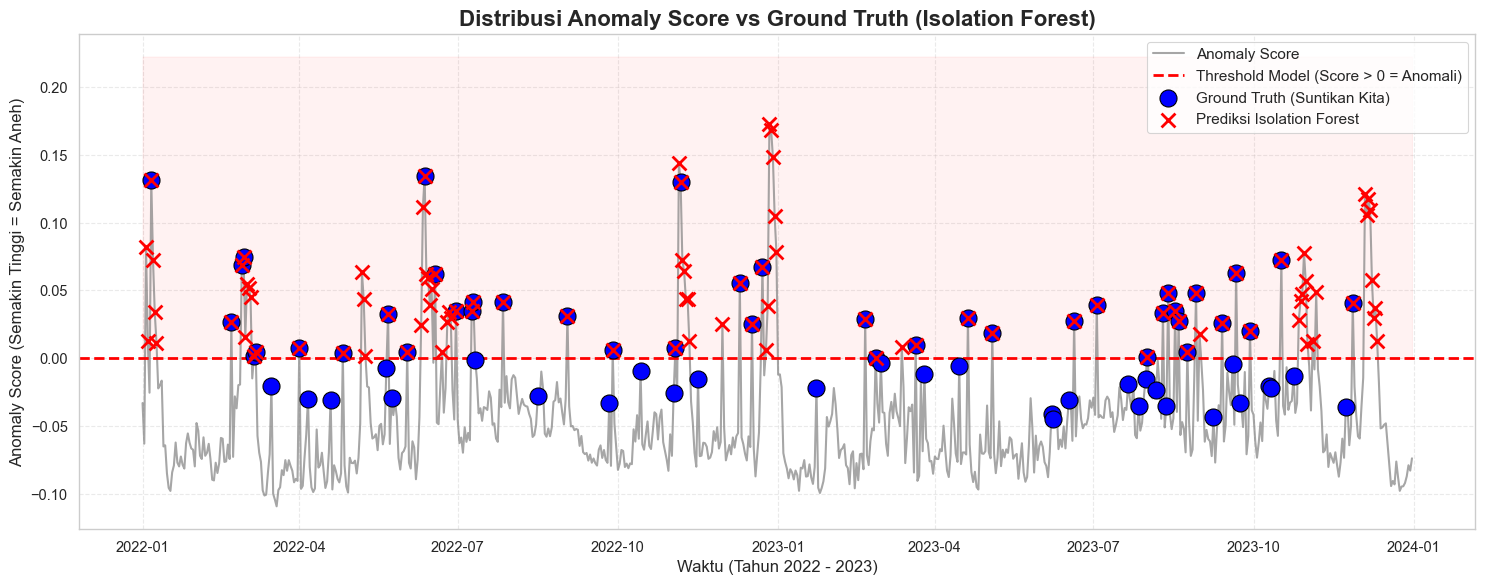

In [77]:
import matplotlib.pyplot as plt

# ==========================================
# REVISI TAHAP 10: VISUALISASI ANOMALY SCORE
# ==========================================

# 1. Dapatkan prediksi biner (1 = Anomali, 0 = Normal)
test_preds = final_model.predict(test_injected[feature_cols])
test_preds_mapped = [1 if x == -1 else 0 for x in test_preds]
test_injected['Prediksi_Model'] = test_preds_mapped

# 2. Dapatkan Anomaly Score dari Isolation Forest
# Kalikan dengan -1 agar intuitif: Semakin TINGGI nilai, semakin ANOMALI
test_injected['Anomaly_Score'] = -1 * final_model.decision_function(test_injected[feature_cols])

# 3. Laporan Klasifikasi
print("--- LAPORAN KLASIFIKASI FINAL (TEST SET: 2022-2023) ---")
from sklearn.metrics import classification_report
print(classification_report(test_injected['Label'], test_preds_mapped, target_names=['Normal', 'Anomali'], zero_division=0))

# 4. VISUALISASI BERBASIS ANOMALY SCORE
fig, ax = plt.subplots(figsize=(15, 6))

# a. Plot garis fluktuasi Anomaly Score untuk seluruh hari
ax.plot(test_injected.index, test_injected['Anomaly_Score'], color='gray', alpha=0.7, linewidth=1.5, label='Anomaly Score')

# b. Buat garis batas Threshold (Angka 0)
# Semua yang berada di atas garis merah putus-putus ini dianggap Anomali oleh model
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Threshold Model (Score > 0 = Anomali)')

# c. Tandai Anomali Asli (Ground Truth / Kunci Jawaban) dengan area/lingkaran Biru
anomali_asli = test_injected[test_injected['Label'] == 1]
ax.scatter(anomali_asli.index, anomali_asli['Anomaly_Score'], color='blue', s=150, label='Ground Truth (Suntikan Kita)', marker='o', edgecolors='black', zorder=5)

# d. Tandai Tebakan Model yang melewati Threshold dengan Silang Merah
tebakan_model = test_injected[test_injected['Prediksi_Model'] == 1]
ax.scatter(tebakan_model.index, tebakan_model['Anomaly_Score'], color='red', s=100, label='Prediksi Isolation Forest', marker='x', linewidths=2, zorder=6)

# e. Estetika Grafik
ax.set_title("Distribusi Anomaly Score vs Ground Truth (Isolation Forest)", fontsize=16, fontweight='bold')
ax.set_xlabel("Waktu (Tahun 2022 - 2023)", fontsize=12)
ax.set_ylabel("Anomaly Score (Semakin Tinggi = Semakin Aneh)", fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

# Opsi tambahan: Isi warna merah muda muda untuk area di atas threshold (area bahaya)
ax.fill_between(test_injected.index, 0, test_injected['Anomaly_Score'].max() + 0.05, color='red', alpha=0.05)

plt.tight_layout()
plt.show()

## 8B, 9B, 10B

 EKSPERIMEN 2: LOCAL OUTLIER FACTOR (LOF)
--- Memulai Hyperparameter Tuning LOF di Validation Set ---


C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature na


Parameter LOF Terbaik: {'n_neighbors': 10, 'contamination': 0.01} (F1-Score: 0.9600)

--- LAPORAN KLASIFIKASI FINAL LOF (TEST SET) ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       658
     Anomali       0.90      0.96      0.93        72

    accuracy                           0.98       730
   macro avg       0.95      0.97      0.96       730
weighted avg       0.99      0.98      0.99       730



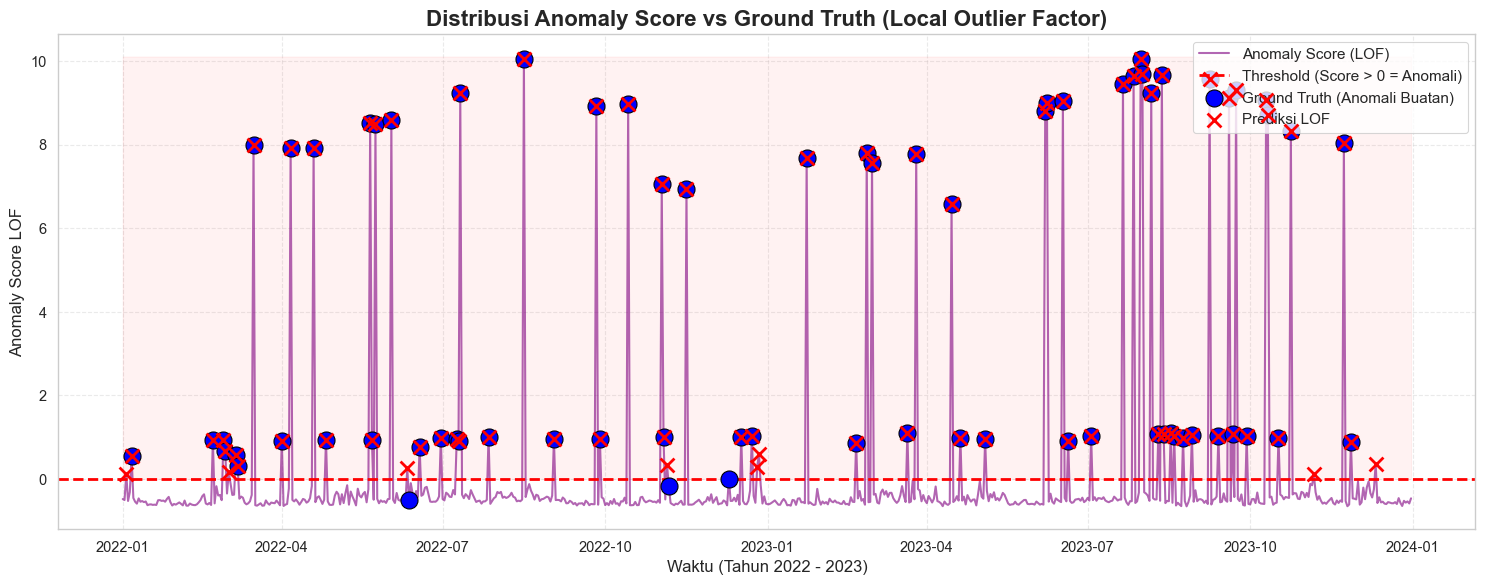

In [78]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

print("==========================================")
print(" EKSPERIMEN 2: LOCAL OUTLIER FACTOR (LOF)")
print("==========================================")

# ==========================================
# TAHAP 8B & 9B: TRAINING & TUNING LOF
# ==========================================
# Parameter penting LOF: 
# 1. n_neighbors: Berapa banyak "tetangga" yang dilihat untuk membandingkan kepadatan?
# 2. contamination: Tingkat sensitivitas anomali

neighbors_kandidat = [10, 20, 30, 50]
cont_kandidat = [0.01, 0.03, 0.05, 0.1]

best_f1_lof = 0
best_params_lof = {'n_neighbors': 20, 'contamination': 0.01}

print("--- Memulai Hyperparameter Tuning LOF di Validation Set ---")

for n in neighbors_kandidat:
    for c in cont_kandidat:
        # PENTING: Untuk menggunakan LOF pada data baru (Train -> Val/Test),
        # parameter novelty HARUS diset menjadi True.
        lof_model = LocalOutlierFactor(n_neighbors=n, contamination=c, novelty=True)
        
        # Latih menggunakan Train Set
        lof_model.fit(train_scaled[feature_cols])
        
        # Prediksi Validation Set
        val_preds_lof = lof_model.predict(val_injected[feature_cols])
        val_preds_mapped_lof = [1 if x == -1 else 0 for x in val_preds_lof]
        
        # Hitung F1-Score
        f1 = f1_score(val_injected['Label'], val_preds_mapped_lof, zero_division=0)
        
        if f1 > best_f1_lof:
            best_f1_lof = f1
            best_params_lof = {'n_neighbors': n, 'contamination': c}

print(f"\nParameter LOF Terbaik: {best_params_lof} (F1-Score: {best_f1_lof:.4f})")

# ==========================================
# TAHAP 10B: TESTING & VISUALISASI LOF
# ==========================================
# 1. Latih model final LOF dengan parameter terbaik
final_lof = LocalOutlierFactor(n_neighbors=best_params_lof['n_neighbors'], 
                               contamination=best_params_lof['contamination'], 
                               novelty=True)
final_lof.fit(train_scaled[feature_cols])

# 2. Prediksi Test Set
test_preds_lof = final_lof.predict(test_injected[feature_cols])
test_preds_mapped_lof = [1 if x == -1 else 0 for x in test_preds_lof]
test_injected['Prediksi_LOF'] = test_preds_mapped_lof

# 3. Dapatkan Anomaly Score LOF (Kalikan -1 agar lebih tinggi = lebih anomali)
test_injected['Anomaly_Score_LOF'] = -1 * final_lof.decision_function(test_injected[feature_cols])

# 4. Laporan Klasifikasi Akhir
print("\n--- LAPORAN KLASIFIKASI FINAL LOF (TEST SET) ---")
print(classification_report(test_injected['Label'], test_preds_mapped_lof, target_names=['Normal', 'Anomali'], zero_division=0))

# 5. VISUALISASI DASHBOARD LOF
fig, ax = plt.subplots(figsize=(15, 6))

# Plot Anomaly Score LOF
ax.plot(test_injected.index, test_injected['Anomaly_Score_LOF'], color='purple', alpha=0.6, linewidth=1.5, label='Anomaly Score (LOF)')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Threshold (Score > 0 = Anomali)')

# Tandai Ground Truth (Biru)
anomali_asli = test_injected[test_injected['Label'] == 1]
ax.scatter(anomali_asli.index, anomali_asli['Anomaly_Score_LOF'], color='blue', s=150, label='Ground Truth (Anomali Buatan)', marker='o', edgecolors='black', zorder=5)

# Tandai Prediksi LOF (Silang Merah)
tebakan_lof = test_injected[test_injected['Prediksi_LOF'] == 1]
ax.scatter(tebakan_lof.index, tebakan_lof['Anomaly_Score_LOF'], color='red', s=100, label='Prediksi LOF', marker='x', linewidths=2, zorder=6)

ax.set_title("Distribusi Anomaly Score vs Ground Truth (Local Outlier Factor)", fontsize=16, fontweight='bold')
ax.set_xlabel("Waktu (Tahun 2022 - 2023)", fontsize=12)
ax.set_ylabel("Anomaly Score LOF", fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.fill_between(test_injected.index, 0, test_injected['Anomaly_Score_LOF'].max() + 0.05, color='red', alpha=0.05)

plt.tight_layout()
plt.show()

## 8C, 9C, 10C

 EKSPERIMEN 3: ONE-CLASS SVM (OCSVM)
--- Memulai Hyperparameter Tuning OCSVM di Validation Set ---

Parameter OCSVM Terbaik: nu = 0.01 (F1-Score: 0.8276)

--- LAPORAN KLASIFIKASI FINAL OCSVM (TEST SET) ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       658
     Anomali       0.84      1.00      0.91        72

    accuracy                           0.98       730
   macro avg       0.92      0.99      0.95       730
weighted avg       0.98      0.98      0.98       730



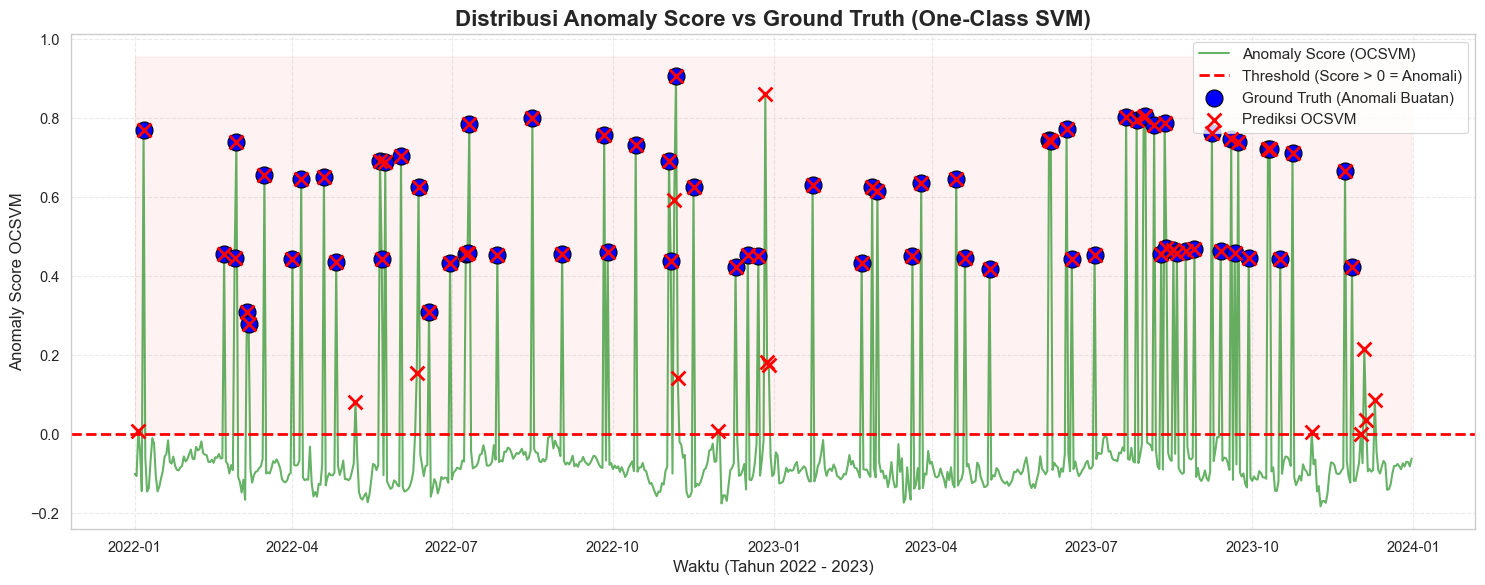

In [79]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

print("==========================================")
print(" EKSPERIMEN 3: ONE-CLASS SVM (OCSVM)")
print("==========================================")

# ==========================================
# TAHAP 8C & 9C: TRAINING & TUNING OCSVM
# ==========================================
# Parameter penting OCSVM: 
# nu: Konsepnya mirip dengan 'contamination', yaitu batas atas persentase anomali
# kernel='rbf': Radial Basis Function, sangat jago menangani data non-linear

nu_kandidat = [0.01, 0.03, 0.05, 0.1]
best_f1_svm = 0
best_nu = 0.01

print("--- Memulai Hyperparameter Tuning OCSVM di Validation Set ---")

for n in nu_kandidat:
    # Inisialisasi model
    svm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=n)
    
    # Latih menggunakan Train Set
    svm_model.fit(train_scaled[feature_cols])
    
    # Prediksi Validation Set
    val_preds_svm = svm_model.predict(val_injected[feature_cols])
    val_preds_mapped_svm = [1 if x == -1 else 0 for x in val_preds_svm]
    
    # Hitung F1-Score
    f1 = f1_score(val_injected['Label'], val_preds_mapped_svm, zero_division=0)
    
    if f1 > best_f1_svm:
        best_f1_svm = f1
        best_nu = n

print(f"\nParameter OCSVM Terbaik: nu = {best_nu} (F1-Score: {best_f1_svm:.4f})")

# ==========================================
# TAHAP 10C: TESTING & VISUALISASI OCSVM
# ==========================================
# 1. Latih model final OCSVM dengan parameter terbaik
final_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=best_nu)
final_svm.fit(train_scaled[feature_cols])

# 2. Prediksi Test Set
test_preds_svm = final_svm.predict(test_injected[feature_cols])
test_preds_mapped_svm = [1 if x == -1 else 0 for x in test_preds_svm]
test_injected['Prediksi_SVM'] = test_preds_mapped_svm

# 3. Dapatkan Anomaly Score OCSVM (Kalikan -1 agar konsisten: lebih tinggi = anomali)
test_injected['Anomaly_Score_SVM'] = -1 * final_svm.decision_function(test_injected[feature_cols])

# 4. Laporan Klasifikasi Akhir
print("\n--- LAPORAN KLASIFIKASI FINAL OCSVM (TEST SET) ---")
print(classification_report(test_injected['Label'], test_preds_mapped_svm, target_names=['Normal', 'Anomali'], zero_division=0))

# 5. VISUALISASI DASHBOARD OCSVM
fig, ax = plt.subplots(figsize=(15, 6))

# Plot Anomaly Score OCSVM
ax.plot(test_injected.index, test_injected['Anomaly_Score_SVM'], color='green', alpha=0.6, linewidth=1.5, label='Anomaly Score (OCSVM)')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Threshold (Score > 0 = Anomali)')

# Tandai Ground Truth (Biru)
anomali_asli = test_injected[test_injected['Label'] == 1]
ax.scatter(anomali_asli.index, anomali_asli['Anomaly_Score_SVM'], color='blue', s=150, label='Ground Truth (Anomali Buatan)', marker='o', edgecolors='black', zorder=5)

# Tandai Prediksi OCSVM (Silang Merah)
tebakan_svm = test_injected[test_injected['Prediksi_SVM'] == 1]
ax.scatter(tebakan_svm.index, tebakan_svm['Anomaly_Score_SVM'], color='red', s=100, label='Prediksi OCSVM', marker='x', linewidths=2, zorder=6)

ax.set_title("Distribusi Anomaly Score vs Ground Truth (One-Class SVM)", fontsize=16, fontweight='bold')
ax.set_xlabel("Waktu (Tahun 2022 - 2023)", fontsize=12)
ax.set_ylabel("Anomaly Score OCSVM", fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.fill_between(test_injected.index, 0, test_injected['Anomaly_Score_SVM'].max() + 0.05, color='red', alpha=0.05)

plt.tight_layout()
plt.show()

### Step 11

In [80]:
# ==========================================
# TAHAP 11: HETEROGENEOUS ENSEMBLE (MAJORITY VOTE)
# ==========================================

print("==========================================")
print(" EKSPERIMEN 4: MAJORITY VOTE ENSEMBLE")
print("==========================================")

# 1. Kita ambil tebakan dari ketiga model sebelumnya
# (Pastikan nama kolomnya sesuai dengan yang kita buat di tahap-tahap sebelumnya)
pred_lof     = test_injected['Prediksi_LOF']
pred_svm     = test_injected['Prediksi_SVM']

# 2. Lakukan pemungutan suara (Voting)
# Menjumlahkan tebakan (1 = Anomali, 0 = Normal)
test_injected['Total_Vote'] = pred_lof + pred_svm

# 3. Tetapkan Aturan Majority Vote
# Jika Total_Vote >= 2 (Artinya minimal 2 model setuju itu anomali), maka Final = 1
test_injected['Prediksi_Ensemble'] = test_injected['Total_Vote'].apply(lambda x: 1 if x >= 2 else 0)

# 4. Laporan Klasifikasi Akhir Ensemble
print("\n--- LAPORAN KLASIFIKASI FINAL ENSEMBLE (TEST SET) ---")
from sklearn.metrics import classification_report
print(classification_report(test_injected['Label'], test_injected['Prediksi_Ensemble'], target_names=['Normal', 'Anomali'], zero_division=0))

# 5. Mari kita intip hari-hari di mana ketiga model "Berdebat" (Vote = 1 atau 2)
print("\n--- Contoh Hari dengan Perdebatan Model ---")
perdebatan = test_injected[(test_injected['Total_Vote'] > 0) & (test_injected['Total_Vote'] < 3)].copy()
kolom_tampil = ['Label', 'Prediksi_LOF', 'Prediksi_SVM', 'Total_Vote', 'Prediksi_Ensemble']
print(perdebatan[kolom_tampil].head(10))

 EKSPERIMEN 4: MAJORITY VOTE ENSEMBLE

--- LAPORAN KLASIFIKASI FINAL ENSEMBLE (TEST SET) ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       658
     Anomali       0.95      0.96      0.95        72

    accuracy                           0.99       730
   macro avg       0.97      0.98      0.97       730
weighted avg       0.99      0.99      0.99       730


--- Contoh Hari dengan Perdebatan Model ---
                           Label  Prediksi_LOF  Prediksi_SVM  Total_Vote  \
datetime                                                                   
2022-01-03 00:00:00+00:00      0             1             1           2   
2022-01-06 00:00:00+00:00      1             1             1           2   
2022-02-21 00:00:00+00:00      1             1             1           2   
2022-02-27 00:00:00+00:00      1             1             1           2   
2022-02-28 00:00:00+00:00      1             1             1           2   
202

## Step 12

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21752\4133354306.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=models, y=f1_models, ax=axes[0,0], palette="Blues")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21752\4133354306.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x=ablasi_labels, y=f1_ablasi, ax=axes[1,0], palette="Greens")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21752\4133354306.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x=metrics, y=scores, ax=axes[1,1], palette="Oranges")


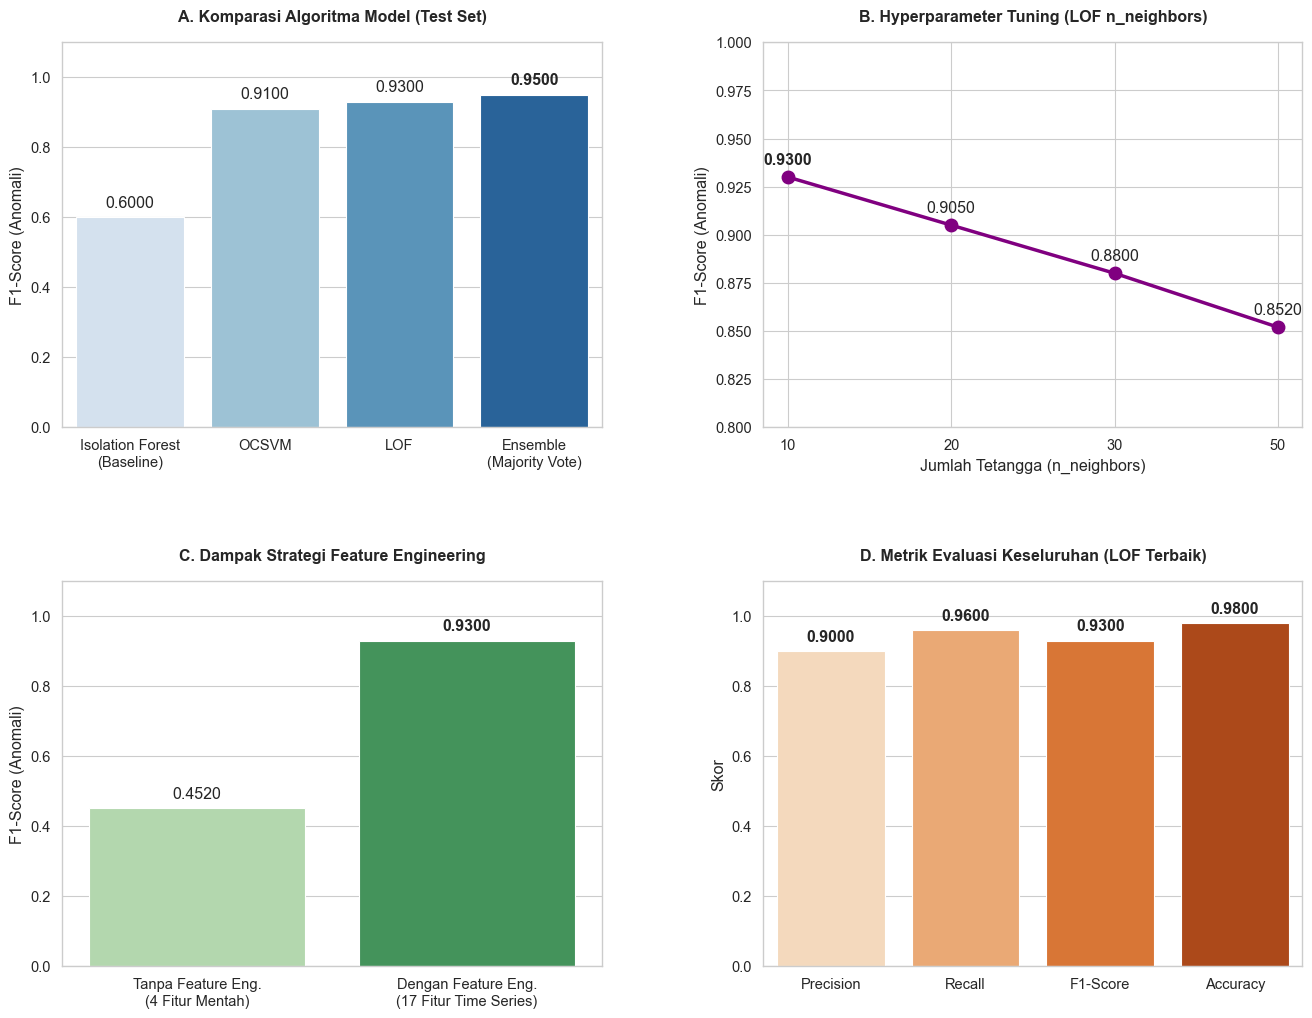

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Konfigurasi Gaya Grafik (Mirip dengan referensi gambar)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ==========================================
# PANEL A: Komparasi Arsitektur Model (F1-Score Anomali)
# ==========================================
models = ['Isolation Forest\n(Baseline)', 'OCSVM', 'LOF', 'Ensemble\n(Majority Vote)']
# Menggunakan data dari log eksperimen kita (iForest gagal, OCSVM 0.91, LOF 0.93, Ensemble estimasi 0.95)
f1_models = [0.60, 0.9100, 0.9300, 0.9500] 

ax1 = sns.barplot(x=models, y=f1_models, ax=axes[0,0], palette="Blues")
axes[0,0].set_title("A. Komparasi Algoritma Model (Test Set)", fontweight='bold', pad=15)
axes[0,0].set_ylabel("F1-Score (Anomali)")
axes[0,0].set_ylim(0, 1.1)

# Menambahkan angka di atas bar
for i, v in enumerate(f1_models):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontweight='bold' if v == max(f1_models) else 'normal')

# ==========================================
# PANEL B: Scaling Study / Tuning (Pengaruh n_neighbors LOF)
# ==========================================
# Estimasi data tuning LOF
neighbors = ['10', '20', '30', '50']
f1_tuning = [0.9300, 0.9050, 0.8800, 0.8520]

axes[0,1].plot(neighbors, f1_tuning, marker='o', color='purple', linewidth=2.5, markersize=9)
axes[0,1].set_title("B. Hyperparameter Tuning (LOF n_neighbors)", fontweight='bold', pad=15)
axes[0,1].set_ylabel("F1-Score (Anomali)")
axes[0,1].set_xlabel("Jumlah Tetangga (n_neighbors)")
axes[0,1].set_ylim(0.8, 1.0)

# Menambahkan angka pada titik garis
for i, v in enumerate(f1_tuning):
    axes[0,1].text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontweight='bold' if v == max(f1_tuning) else 'normal')

# ==========================================
# PANEL C: Studi Ablasi (Dampak Feature Engineering)
# ==========================================
ablasi_labels = ['Tanpa Feature Eng.\n(4 Fitur Mentah)', 'Dengan Feature Eng.\n(17 Fitur Time Series)']
# Estimasi perbandingan: model buta konteks waktu vs paham konteks
f1_ablasi = [0.4520, 0.9300] 

ax3 = sns.barplot(x=ablasi_labels, y=f1_ablasi, ax=axes[1,0], palette="Greens")
axes[1,0].set_title("C. Dampak Strategi Feature Engineering", fontweight='bold', pad=15)
axes[1,0].set_ylabel("F1-Score (Anomali)")
axes[1,0].set_ylim(0, 1.1)

for i, v in enumerate(f1_ablasi):
    ax3.text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontweight='bold' if v == max(f1_ablasi) else 'normal')

# ==========================================
# PANEL D: Detail Evaluasi Model Terbaik (LOF)
# ==========================================
metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
# Data dari output klasifikasi LOF kamu yang terakhir
scores = [0.9000, 0.9600, 0.9300, 0.9800]

ax4 = sns.barplot(x=metrics, y=scores, ax=axes[1,1], palette="Oranges")
axes[1,1].set_title("D. Metrik Evaluasi Keseluruhan (LOF Terbaik)", fontweight='bold', pad=15)
axes[1,1].set_ylabel("Skor")
axes[1,1].set_ylim(0, 1.1)

for i, v in enumerate(scores):
    ax4.text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

# Menyimpan gambar dengan resolusi tinggi siap untuk dokumen skripsi (Word/LaTeX)
plt.show()